<a href="https://colab.research.google.com/github/AngusFothers/FakeNewDetectionTool/blob/main/Final_Report_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("emineyetm/fake-news-detection-datasets")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/fake-news-detection-datasets


            MODEL PERFORMANCE METRICS             
Accuracy:      98.74% 
Precision:     99.23% 
Recall:        98.38%

Testing with sample news articles:

Prediction Analysis:
- Probability of being fake: 9.77%
- Final prediction: True news

Prediction Analysis:
- Probability of being fake: 93.23%
- Final prediction: Fake news


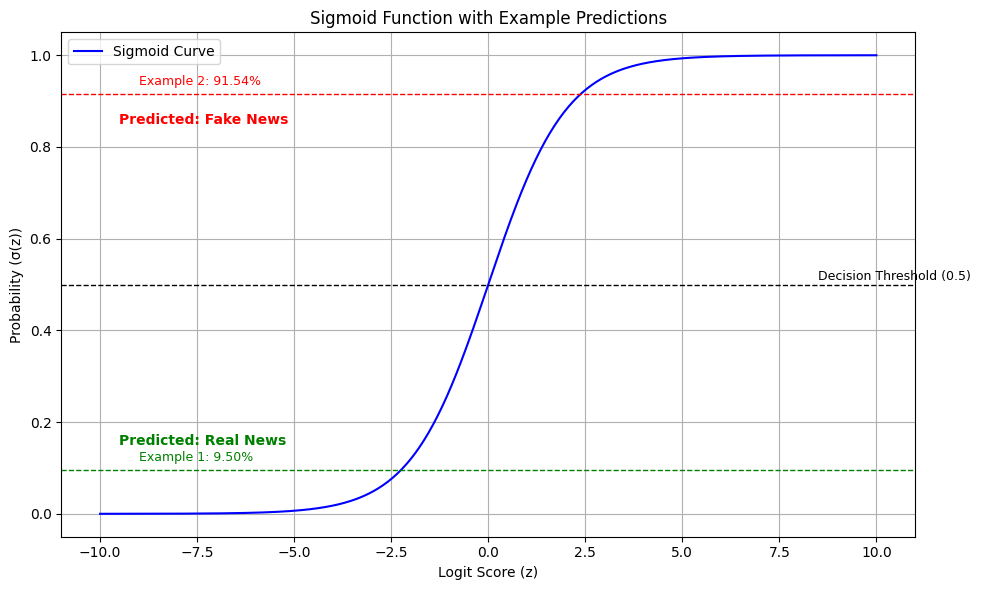

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, classification_report


true_data = pd.read_csv('/kaggle/input/fake-news-detection-datasets/News _dataset/True.csv')
fake_data = pd.read_csv('/kaggle/input/fake-news-detection-datasets/News _dataset/Fake.csv')
true_data['label'] = 0
fake_data['label'] = 1


all_data = pd.concat([true_data, fake_data]).sample(frac=1).reset_index(drop=True)
all_data['text_combined'] = all_data['title'] + ' ' + all_data['text']

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(all_data['text_combined'])
y = all_data['label']

#Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


#Prediction
def predict_news(headline, content):
    combined = headline + ' ' + content
    vec = vectorizer.transform([combined])
    prob = model.predict_proba(vec)[0][1]
    prediction = model.predict(vec)[0]

    print("\nPrediction Analysis:")
    print(f"- Probability of being fake: {prob:.2%}")
    print(f"- Final prediction: {'Fake news' if prediction == 1 else 'True news'}")
    return prediction

predictions = model.predict(X_test)

#Displaying Results
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)

print("MODEL PERFORMANCE METRICS".center(50))
print(f"{'Accuracy:':<15}{accuracy:.2%} ")
print(f"{'Precision:':<15}{precision:.2%} ")
print(f"{'Recall:':<15}{recall:.2%}")


# Example predictions
print("\nTesting with sample news articles:")
result1 = predict_news(
    "Cameroonian journalist to be freed after terrorism charges dropped",
    "YAOUNDE (Reuters) - A Cameroonian journalist jailed for over two years for contact with Islamist"
)

result2 = predict_news(
    "Breaking: Aliens land in New York!",
    "Scientists confirm extraterrestrial visitors have landed in Times Square."
)

import matplotlib.pyplot as plt
import numpy as np


# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(z, sig, label='Sigmoid Curve', color='blue')
plt.title('Sigmoid Function with Example Predictions')
plt.xlabel('Logit Score (z)')
plt.ylabel('Probability (σ(z))')
plt.grid(True)

# Add decision boundary at probability = 0.5
plt.axhline(y=0.5, color='black', linestyle='--', linewidth=1)
plt.text(8.5, 0.51, 'Decision Threshold (0.5)', color='black', fontsize=9)

# Add region labels
plt.text(-9.5, 0.85, 'Predicted: Fake News', color='red', fontsize=10, weight='bold')
plt.text(-9.5, 0.15, 'Predicted: Real News', color='green', fontsize=10, weight='bold')

# Mark prediction probabilities
for i, prob in enumerate(probs):
    color = 'red' if prob >= 0.5 else 'green'
    plt.axhline(y=prob, color=color, linestyle='--', linewidth=1)
    plt.text(-9, prob + 0.02, f'Example {i+1}: {prob:.2%}', color=color, fontsize=9)

plt.legend()
plt.tight_layout()
plt.show()
